In [70]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [71]:
t_matrix = np.load("transfer_matrix.npy")
print(t_matrix)

[[1.         0.9909808  0.91602206 0.90502185 0.81652492 0.79759037
  0.78696162 0.77475244 0.42299575 0.12739727]
 [0.99322039 0.99999994 0.91270715 0.90174675 0.81530988 0.80120486
  0.79045403 0.77599007 0.42088607 0.130137  ]
 [0.94915259 0.95264935 0.99999994 0.93013102 0.83718109 0.80481929
  0.78928989 0.78589106 0.41877636 0.12739727]
 [0.91751415 0.92220968 0.94364637 1.         0.8116647  0.79518074
  0.7718277  0.76732671 0.4398734  0.12191781]
 [0.859887   0.86696726 0.85193366 0.84716159 1.         0.89638555
  0.79627472 0.9022277  0.44725737 0.19863014]
 [0.86101699 0.87260425 0.85856348 0.84934497 0.90400976 1.
  0.82072181 0.89108908 0.44725737 0.18630138]
 [0.85649717 0.86696726 0.83977896 0.84934497 0.78493321 0.78313255
  1.         0.74628711 0.41983122 0.12191781]
 [0.83615822 0.84329194 0.82430935 0.83515286 0.92588097 0.89156628
  0.79627472 1.         0.45253164 0.20410959]
 [0.79209042 0.79706872 0.78011048 0.82314414 0.72661    0.71325302
  0.72642606 0.70668

In [72]:
all_stats = np.load("gaas_overall_stats.npy")
print(all_stats)

[[[4.94019359e-01 2.38118467e+01 4.81355876e-01 2.22222222e+01]
  [2.40248099e-01 2.34823009e+01 2.41582826e-01 2.10223048e+01]
  [2.03264058e-01 2.36407767e+01 1.85272932e-01 2.28271605e+01]
  [1.83365017e-01 2.28967742e+01 1.09575748e-01 2.38381503e+01]
  [1.31224155e-01 2.47951807e+01 1.48714438e-01 2.02079208e+01]
  [1.15271404e-01 2.36355140e+01 1.11164644e-01 2.25813953e+01]
  [1.24023899e-01 2.18253012e+01 1.18410416e-01 2.04690722e+01]
  [1.05424762e-01 2.40142857e+01 1.05035603e-01 2.23000000e+01]
  [5.50705800e-03 2.78115183e+01 4.86997748e-03 2.78918919e+01]
  [5.81905525e-03 3.01510791e+01 6.25466090e-03 2.87821229e+01]]

 [[2.40248099e-01 2.34823009e+01 2.41582826e-01 2.10223048e+01]
  [5.16751528e-01 2.11120690e+01 5.18616974e-01 1.88394161e+01]
  [1.54318824e-01 2.18863636e+01 1.51788160e-01 2.09299065e+01]
  [1.50264353e-01 2.13382353e+01 9.54180881e-02 2.13987342e+01]
  [1.24744706e-01 2.39242424e+01 1.35070249e-01 1.96202532e+01]
  [9.97772589e-02 2.54146341e+01 8.897

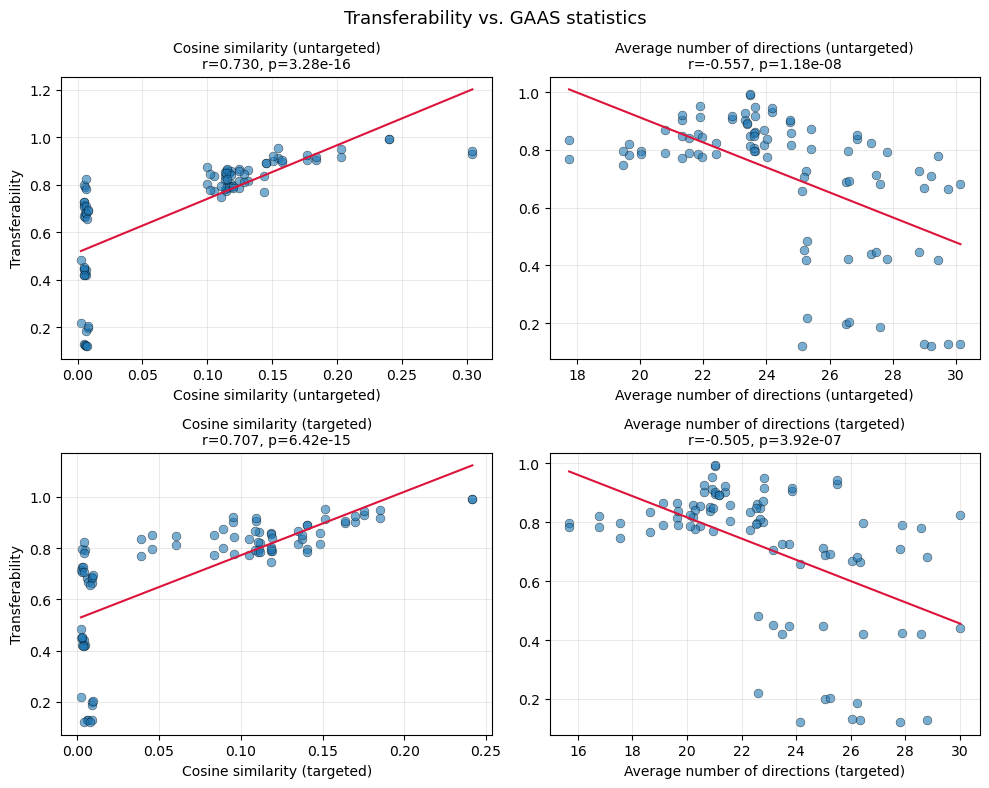

In [74]:
STAT_NAMES = [
    ("coss_u", "Cosine similarity (untargeted)"),
    ("ds_u",   "Average number of directions (untargeted)"),
    ("coss_t", "Cosine similarity (targeted)"),
    ("ds_t",   "Average number of directions (targeted)"),
]

def correlate_and_visualize(transfer_matrix: np.ndarray, stat_matrix: np.ndarray, exclude_diagonal: bool = True):
    
    n = transfer_matrix.shape[0]
    off_diag = ~np.eye(n, dtype=bool) if exclude_diagonal else np.ones((n, n), dtype=bool)
    transfer_flat = transfer_matrix[off_diag]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle("Transferability vs. GAAS statistics", fontsize=13)
    axes = axes.flatten()  

    for i, (_, label) in enumerate(STAT_NAMES):
        ax = axes[i]
        stat_flat = stat_matrix[:, :, i][off_diag]

        mask = ~np.isnan(transfer_flat) & ~np.isnan(stat_flat)
        x = stat_flat[mask]
        y = transfer_flat[mask]

        r, p = stats.pearsonr(x, y)

        ax.scatter(x, y, alpha=0.6, edgecolors="k", linewidths=0.4, s=40)

        m, b = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, m * x_line + b, color="crimson", linewidth=1.5)

        ax.set_title(f"{label}\nr={r:.3f}, p={p:.2e}", fontsize=10)
        ax.set_xlabel(label)
        ax.set_ylabel("Transferability" if i % 2 == 0 else "")
        ax.grid(True, linewidth=0.4, alpha=0.5)

    plt.tight_layout()
    plt.savefig("transfer_vs_stats.png", dpi=150)
    plt.show()
    
correlate_and_visualize(t_matrix, all_stats, exclude_diagonal=True)